In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import scipy.stats as stats

In [2]:
master_df = pd.read_csv("../data/processed/master_dataset_v2.csv")
df = master_df.copy()

In [3]:
df_no_dc = df[df["state"] != "District of Columbia"].copy()

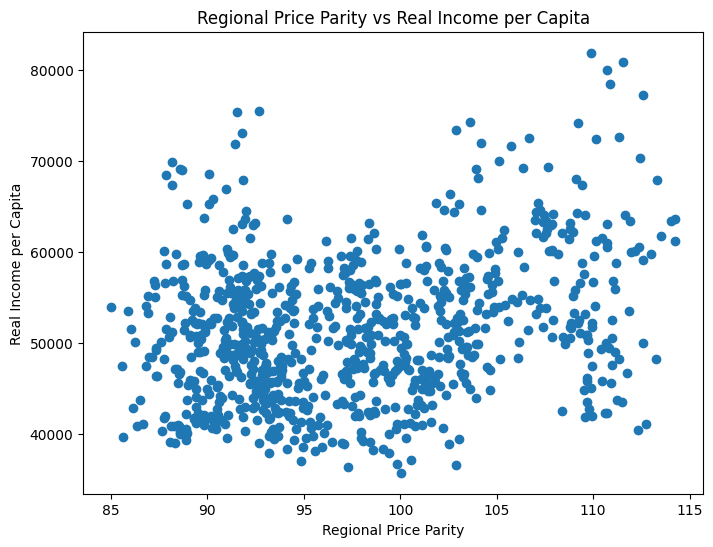

In [4]:
plt.figure(figsize=(8,6))
plt.scatter(df["rpp"], df["real_income_pc"])
plt.xlabel("Regional Price Parity")
plt.ylabel("Real Income per Capita")
plt.title("Regional Price Parity vs Real Income per Capita")
plt.show()

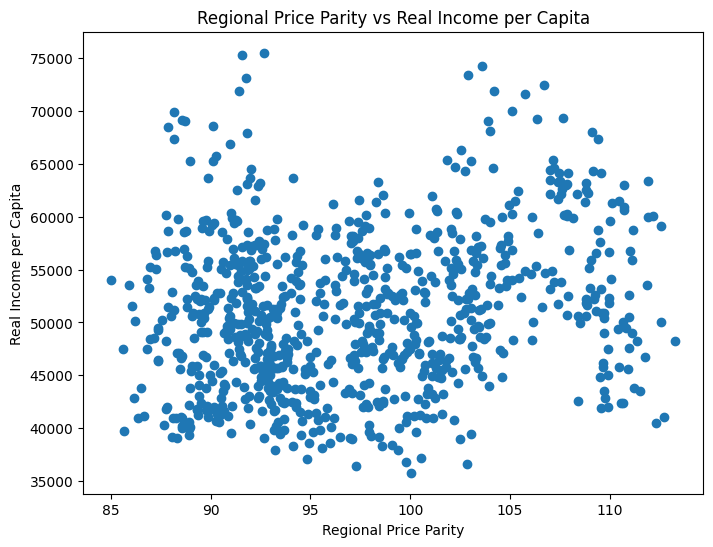

In [5]:
plt.figure(figsize=(8,6))
plt.scatter(df_no_dc["rpp"], df_no_dc["real_income_pc"])
plt.xlabel("Regional Price Parity")
plt.ylabel("Real Income per Capita")
plt.title("Regional Price Parity vs Real Income per Capita")
plt.show()

In [6]:
df_no_dc["rpp"].corr(df_no_dc["real_income_pc"])

np.float64(0.20793554700693287)

In [7]:
import statsmodels.api as sm

# Perform linear regression
X = df_no_dc[['rpp']]
y = df_no_dc['real_income_pc']
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:         real_income_pc   R-squared:                       0.043
Model:                            OLS   Adj. R-squared:                  0.042
Method:                 Least Squares   F-statistic:                     38.32
Date:                Wed, 22 Apr 2026   Prob (F-statistic):           9.33e-10
Time:                        14:28:35   Log-Likelihood:                -8748.6
No. Observations:                 850   AIC:                         1.750e+04
Df Residuals:                     848   BIC:                         1.751e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       2.891e+04   3575.501      8.086      0.0

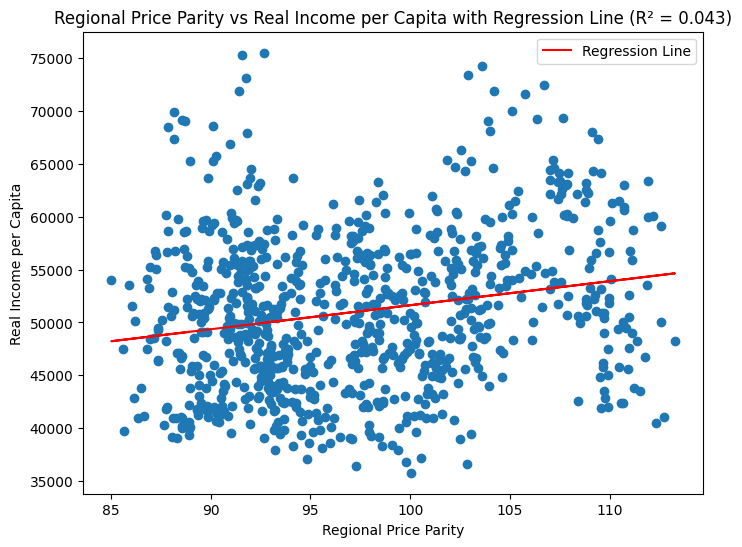

In [8]:
plt.figure(figsize=(8,6))
plt.scatter(df_no_dc["rpp"], df_no_dc["real_income_pc"])
plt.plot(df_no_dc["rpp"], model.predict(X), color='red', label='Regression Line')
plt.xlabel("Regional Price Parity")
plt.ylabel("Real Income per Capita")
plt.title(f"Regional Price Parity vs Real Income per Capita with Regression Line (R² = {model.rsquared:.3f})")
plt.legend()
plt.show()

In [9]:
df_no_dc["predicted"] = model.predict(X)
df_no_dc["residual"] = df_no_dc["real_income_pc"] - df_no_dc["predicted"]

In [10]:
# worst
df_no_dc.sort_values("residual").head(20)

,state,year,population,gdp,gdp_pc,employment,employment_pc,income_pc,real_income_pc,rpp,predicted,residual
749,Utah,2009,2723421.0,1.138348e+11,41798.46,1633986.0,0.599976,31796.0,35790.0,100.037,51634.984768,-15844.984768
35,Arizona,2009,6343154.0,2.448622e+11,38602.59,3228516.0,0.508976,33467.0,36634.0,102.865,52277.371724,-15643.371724
751,Utah,2011,2818798.0,1.251378e+11,44394.03,1664413.0,0.590469,34015.0,36773.0,99.813,51584.102633,-14811.102633
36,Arizona,2010,6401304.0,2.505270e+11,39136.87,3181563.0,0.497018,33778.0,37162.0,100.558,51753.331163,-14591.331163
750,Utah,2010,2776212.0,1.182963e+11,42610.69,1620793.0,0.583815,32037.0,36430.0,97.291,51011.224308,-14581.224308
192,Hawaii,2013,1423345.0,7.459850e+10,52410.69,868191.0,0.609965,43548.0,40531.0,112.319,54424.870410,-13893.870410
752,Utah,2012,2861360.0,1.294314e+11,45234.22,1706044.0,0.596235,35622.0,37956.0,99.412,51493.014525,-13537.014525
205,Idaho,2009,1554439.0,5.450790e+10,35065.96,880489.0,0.566435,31200.0,37042.0,94.843,50455.155260,-13413.155260
188,Hawaii,2009,1346717.0,6.446430e+10,47867.74,829885.0,0.616228,41144.0,41102.0,112.715,54514.822756,-13412.822756
34,Arizona,2008,6280362.0,2.610058e+11,41559.04,3402806.0,0.541817,35586.0,38966.0,102.504,52195.369712,-13229.369712


In [11]:
# best
df_no_dc.sort_values("residual").tail(20)

,state,year,population,gdp,gdp_pc,employment,employment_pc,income_pc,real_income_pc,rpp,predicted,residual
474,Nebraska,2023,1988172.0,1.837809e+11,92437.12,1396472.0,0.702390,71517.0,65780.0,90.288,49420.476128,16359.523872
113,Connecticut,2019,3607133.0,2.864519e+11,79412.62,2297925.0,0.637050,74176.0,69091.0,103.915,52515.881733,16575.118267
114,Connecticut,2020,3579643.0,2.787479e+11,77870.31,2217480.0,0.619470,76826.0,70018.0,105.119,52789.373209,17228.626791
591,North Dakota,2021,777977.0,6.483000e+10,83331.51,567429.0,0.729365,66158.0,66878.0,90.962,49573.576838,17304.423162
862,Wyoming,2020,577669.0,3.698270e+10,64020.57,401439.0,0.694929,65093.0,67906.0,91.836,49772.108026,18133.891974
593,North Dakota,2023,787071.0,7.789810e+10,98972.14,597884.0,0.759632,71545.0,67383.0,88.174,48940.275977,18442.724023
373,Massachusetts,2024,7138560.0,7.785234e+11,109058.89,5057930.0,0.708536,93607.0,71629.0,105.757,52934.296433,18694.703567
710,South Dakota,2021,896303.0,6.333770e+10,70665.50,624996.0,0.697304,67174.0,68551.0,90.105,49378.907241,19172.092759
370,Massachusetts,2021,6996721.0,6.503088e+11,92944.80,4777266.0,0.682786,84087.0,72466.0,106.698,53148.046831,19317.953169
117,Connecticut,2023,3641369.0,3.418518e+11,93880.02,2420056.0,0.664601,90235.0,71915.0,104.201,52580.847316,19334.152684


In [12]:
state_avg = df_no_dc.groupby("state")["residual"].mean().sort_values()

In [13]:
#worst
state_avg.head(10)

state
Hawaii           -8769.487953
Arizona          -7198.172320
New Mexico       -6781.599484
Utah             -6163.105110
Mississippi      -5962.213366
Oregon           -5511.075114
Idaho            -5173.023128
West Virginia    -4828.571373
South Carolina   -4760.146543
Georgia          -3902.320978
Name: residual, dtype: float64

In [14]:
#best
state_avg.tail(10)

state
New Hampshire     3155.848855
Iowa              3385.026629
Kansas            3705.731631
Minnesota         3795.520488
Nebraska          6640.316989
Massachusetts     8777.002437
South Dakota      9295.595467
North Dakota     11393.852395
Wyoming          11809.583769
Connecticut      12873.572426
Name: residual, dtype: float64

In [15]:
df_no_dc["rpp_group"] = pd.qcut(df_no_dc["rpp"], 4, labels=["Low", "Mid-Low", "Mid-High", "High"])
df_no_dc.groupby("rpp_group")["residual"].mean()

rpp_group
Low         1419.837633
Mid-Low    -1433.532781
Mid-High   -1570.375708
High        1569.967999
Name: residual, dtype: float64

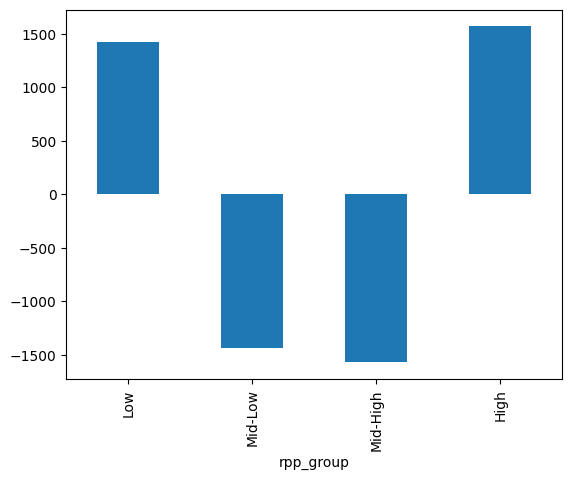

In [16]:
ax = df_no_dc.groupby("rpp_group")["residual"].mean().plot(kind="bar")

In [17]:
groups = [group["residual"].values for name, group in df_no_dc.groupby("rpp_group")]

f_stat, p_value = stats.f_oneway(*groups)
print(p_value)

2.5451159710619838e-08


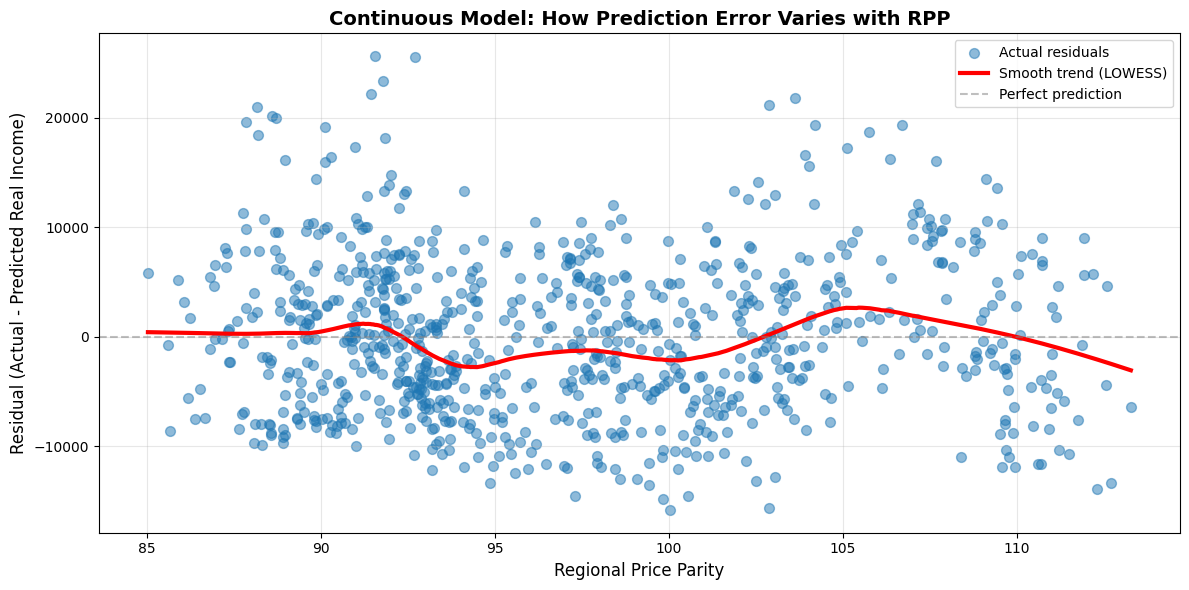

Interpretation: Positive residuals = states earning MORE than RPP predicts
                Negative residuals = states earning LESS than RPP predicts


In [18]:
# Continuous model: smooth relationship between RPP and residuals
from scipy.interpolate import make_interp_spline

# Sort by RPP for plotting
df_sorted = df_no_dc.sort_values('rpp')

# Create a smoother using LOWESS (locally weighted scatterplot smoothing)
from statsmodels.nonparametric.smoothers_lowess import lowess

# Apply LOWESS to residuals vs RPP
residual_smooth = lowess(df_sorted['residual'], df_sorted['rpp'], frac=0.3)

# Plot continuous relationship
fig, ax = plt.subplots(figsize=(12, 6))

# Scatter plot
ax.scatter(df_no_dc['rpp'], df_no_dc['residual'], alpha=0.5, label='Actual residuals', s=50)

# LOWESS smooth curve
ax.plot(residual_smooth[:, 0], residual_smooth[:, 1], 'r-', linewidth=3, label='Smooth trend (LOWESS)')

# Reference line at y=0 (perfect prediction)
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5, label='Perfect prediction')

ax.set_xlabel('Regional Price Parity', fontsize=12)
ax.set_ylabel('Residual (Actual - Predicted Real Income)', fontsize=12)
ax.set_title('Continuous Model: How Prediction Error Varies with RPP', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Interpretation: Positive residuals = states earning MORE than RPP predicts")
print("                Negative residuals = states earning LESS than RPP predicts")

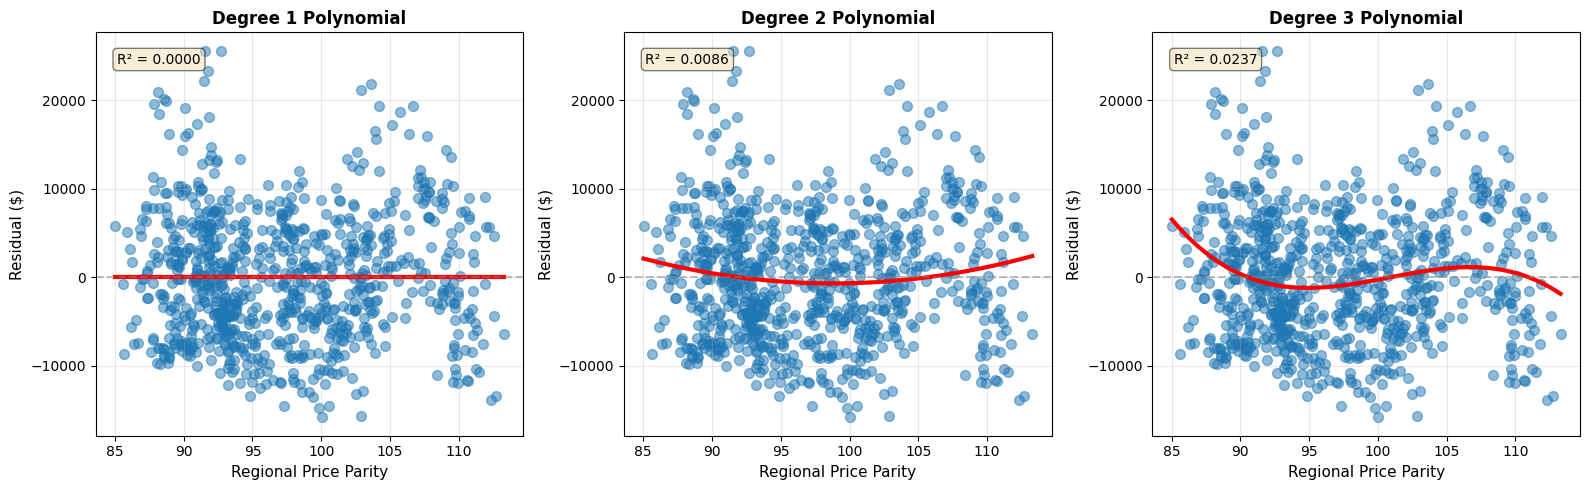

Model Comparison:
Degree 1: R² = 0.0000
Degree 2: R² = 0.0086
Degree 3: R² = 0.0237


In [19]:
# Polynomial regression model to capture non-linearity
from numpy.polynomial import polynomial as P

# Fit polynomial models of different degrees
degrees = [1, 2, 3]
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, deg in enumerate(degrees):
    ax = axes[idx]
    
    # Fit polynomial
    coeffs = np.polyfit(df_no_dc['rpp'], df_no_dc['residual'], deg)
    poly = np.poly1d(coeffs)
    
    # Sort for smooth plotting
    rpp_sorted = np.sort(df_no_dc['rpp'].values)
    residual_pred = poly(rpp_sorted)
    
    # Plot
    ax.scatter(df_no_dc['rpp'], df_no_dc['residual'], alpha=0.5, s=50)
    ax.plot(rpp_sorted, residual_pred, 'r-', linewidth=3)
    ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    
    ax.set_xlabel('Regional Price Parity', fontsize=11)
    ax.set_ylabel('Residual ($)', fontsize=11)
    ax.set_title(f'Degree {deg} Polynomial', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    # Calculate R² for this model
    y_pred = poly(df_no_dc['rpp'])
    ss_res = np.sum((df_no_dc['residual'] - y_pred) ** 2)
    ss_tot = np.sum((df_no_dc['residual'] - df_no_dc['residual'].mean()) ** 2)
    r_squared = 1 - (ss_res / ss_tot)
    ax.text(0.05, 0.95, f'R² = {r_squared:.4f}', transform=ax.transAxes, 
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

print("Model Comparison:")
for deg in degrees:
    coeffs = np.polyfit(df_no_dc['rpp'], df_no_dc['residual'], deg)
    poly = np.poly1d(coeffs)
    y_pred = poly(df_no_dc['rpp'])
    ss_res = np.sum((df_no_dc['residual'] - y_pred) ** 2)
    ss_tot = np.sum((df_no_dc['residual'] - df_no_dc['residual'].mean()) ** 2)
    r_squared = 1 - (ss_res / ss_tot)
    print(f"Degree {deg}: R² = {r_squared:.4f}")